In [3]:
import sys
import re
import json

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import torch
from torch import nn

from pathlib import Path

ROOT = Path("..").resolve()  # repo root
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from check_dataset import summarize_dataset, print_report, plot_global_hist

ARTIFACTS = ROOT / "artifacts"
npz_paths = sorted(ARTIFACTS.glob("*.npz"))

len16_main = []
len16_hist = []
len8_hist = []

for p in ARTIFACTS.glob("*.npz"):
    stem = p.stem
    if "len16" in stem and "hist" in stem and "zh" in stem:
        len16_hist.append(p)
    elif "len8" in stem and "hist" in stem and "en" in stem:
        len8_hist.append(p)
    elif "len16" in stem:
        len16_main.append(p)

/tmp/ipykernel_4119961/2734773107.py:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


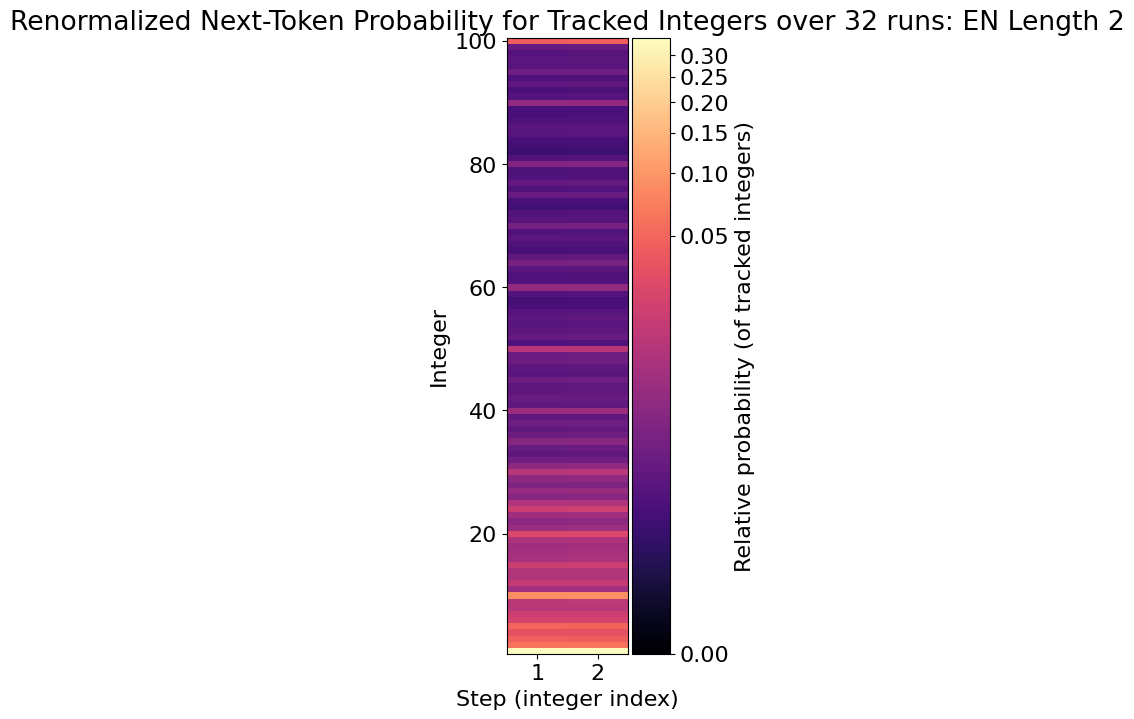

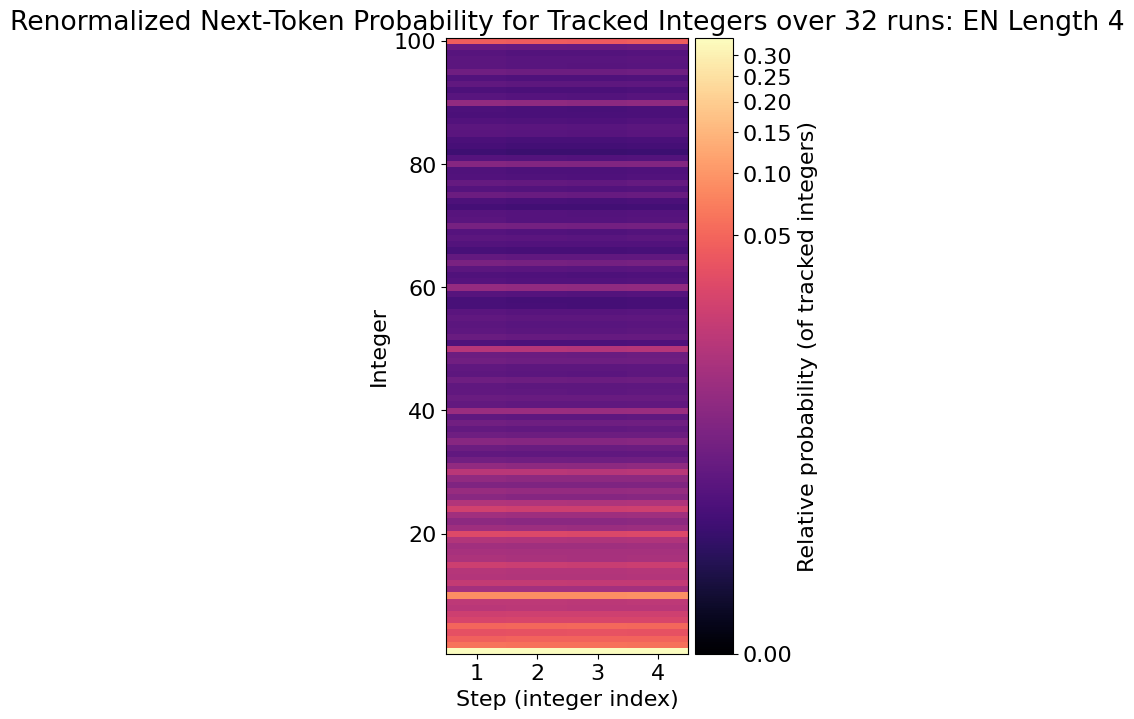

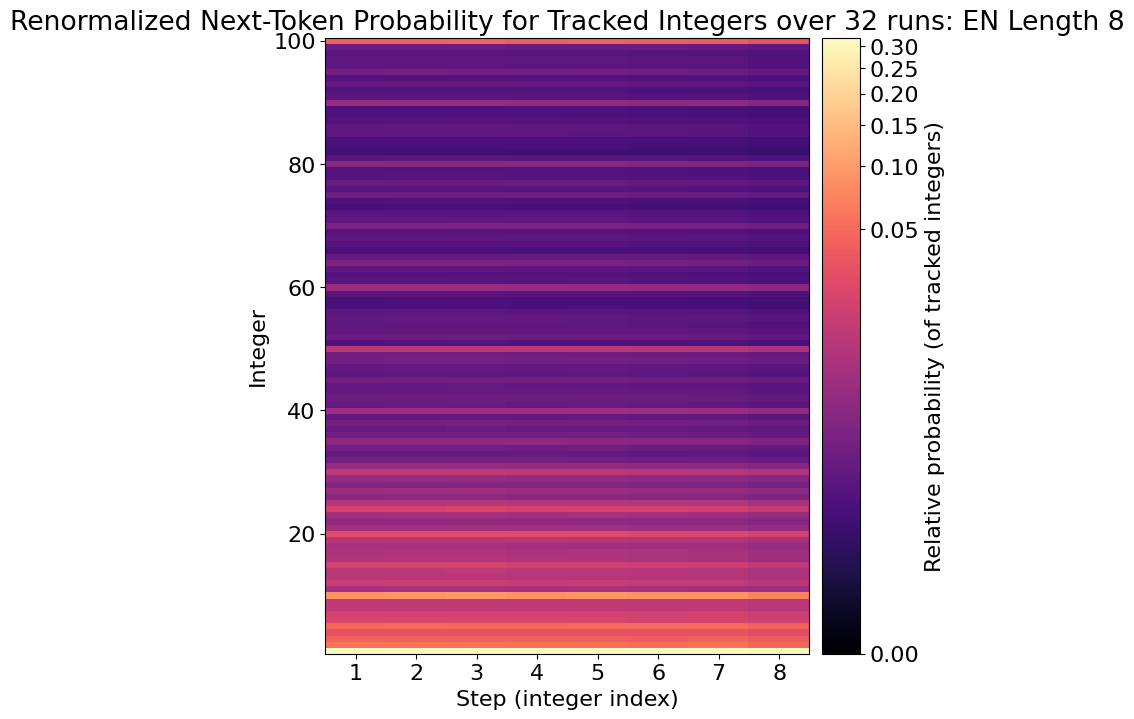

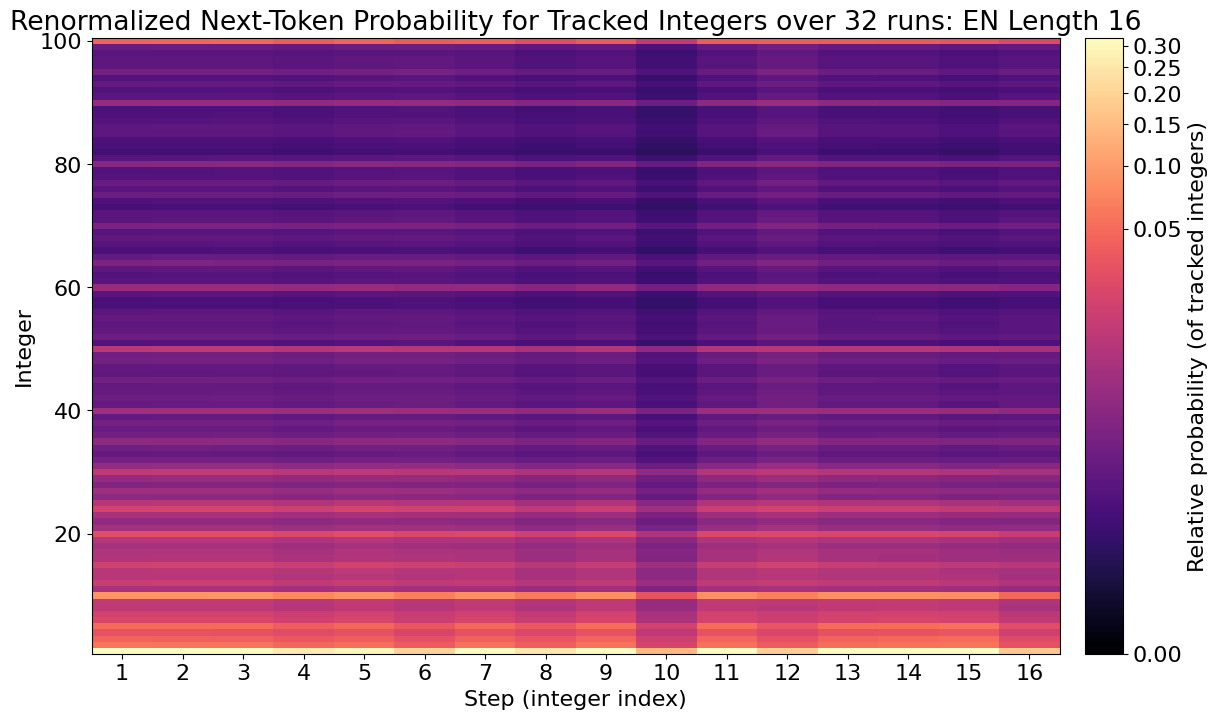

In [28]:
  EN_ROLLOUTS = ROOT / "rollouts" / "en"

  paths = list(EN_ROLLOUTS.glob("*.json"))

  def sort_key(p: Path):
      stem = p.stem
      for part in stem.split("_"):
          if part.startswith("len"):
              try:
                  return int(part.removeprefix("len"))
              except ValueError:
                  return 0
      return 0

  def human_title(path: Path) -> str:
      stem = path.stem
      parts = stem.split("_")
      lang = parts[0].upper() if parts else stem
      length = None
      rollouts = None
      for part in parts:
          if part.startswith("len"):
              try:
                  length = int(part.removeprefix("len"))
              except ValueError:
                  pass
          if part.startswith("rollouts"):
              try:
                  rollouts = int(part.removeprefix("rollouts"))
              except ValueError:
                  pass
      title = "Renormalized Next-Token Probability for Tracked Integers"
      if rollouts is not None:
          title += f" over {rollouts} runs"
      title += f": {lang}"
      if length is not None:
          title += f" Length {length}"
      return title

  for path in sorted(paths, key=sort_key):
      data = json.loads(path.read_text())
      steps = data["per_step_probs"]
      ints = sorted(int(i) for i in steps[0].keys())

      mat = np.array([[step[str(i)] for i in ints] for step in steps], dtype=np.float32)
      mat_rel = mat / (mat.sum(axis=1, keepdims=True) + 1e-12)

      vmax = np.percentile(mat_rel, 99.5)
      norm = colors.PowerNorm(gamma=0.2, vmin=0, vmax=vmax)

      num_steps = mat.shape[0]
      int_span = max(ints) - min(ints) + 1
      per_step_width = 0.8      # inches per step
      cb_width_in = 0.5         # inch width reserved for colorbar
      width = per_step_width * num_steps + cb_width_in
      height = max(3.0, min(8.0, 0.12 * int_span))

      fig = plt.figure(figsize=(width, height))
      gs = fig.add_gridspec(
          nrows=1,
          ncols=2,
          width_ratios=[per_step_width * num_steps, cb_width_in],
          wspace=0.05,
      )
      ax = fig.add_subplot(gs[0, 0])
      cax = fig.add_subplot(gs[0, 1])

      extent = [0.5, num_steps + 0.5, min(ints) - 0.5, max(ints) + 0.5]
      im = ax.imshow(
          mat_rel.T,
          aspect="auto",
          origin="lower",
          extent=extent,
          cmap="magma",
          norm=norm,
      )
      fig.colorbar(im, cax=cax, label="Relative probability (of tracked integers)")

      ax.set_xlabel("Step (integer index)")
      ax.set_ylabel("Integer")
      ax.set_xticks(range(1, num_steps + 1))
      ax.set_title(human_title(path))

      fig.tight_layout()
      fig.savefig(f"{path.name[:-5]}-heatmap.png", dpi=300, bbox_inches="tight")
      plt.show()


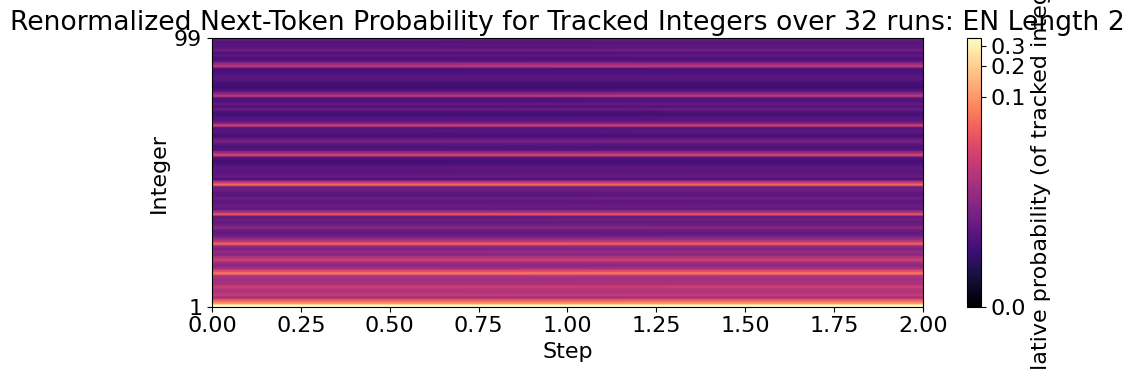

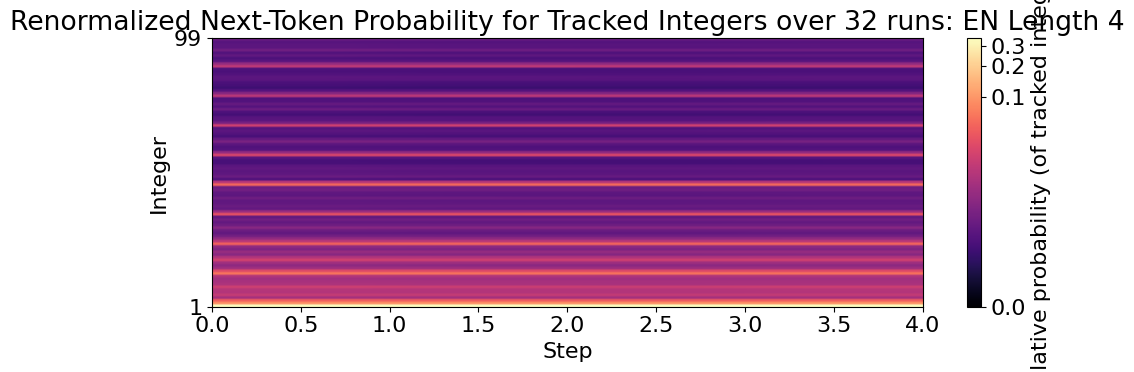

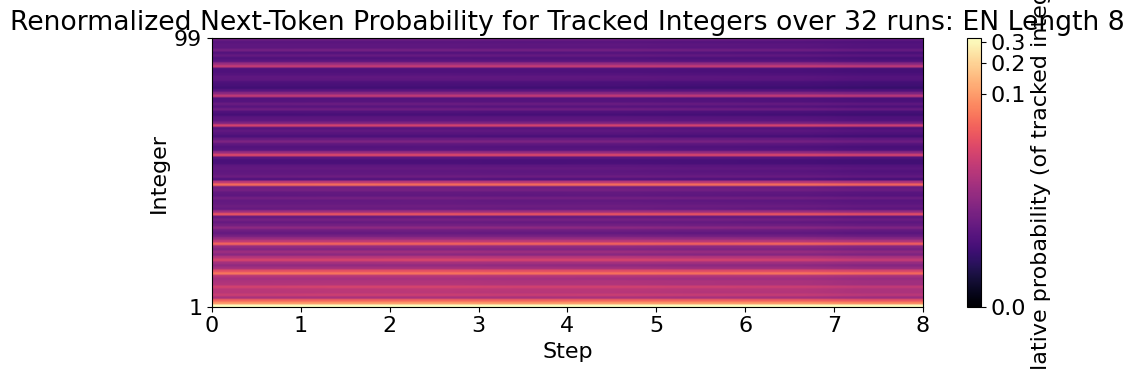

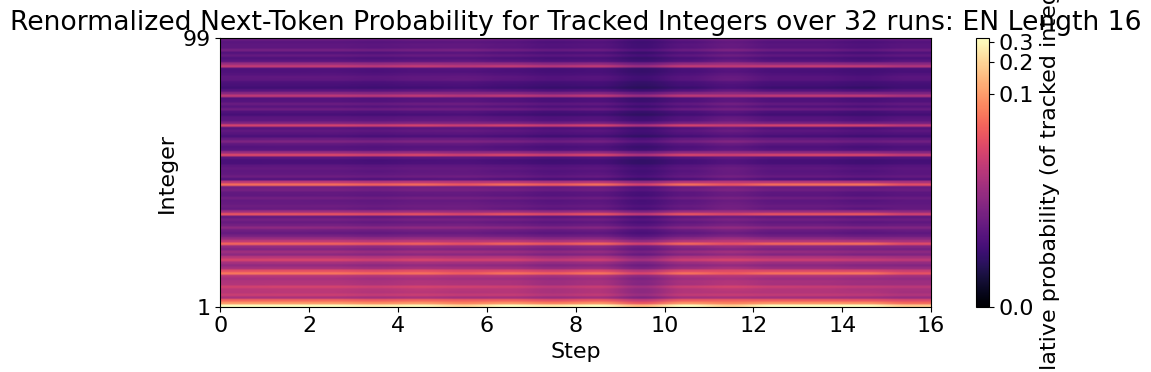

In [23]:
EN_ROLLOUTS = ROOT / 'rollouts' / 'en'

paths = list(EN_ROLLOUTS.glob('*.json'))

def sort_key(p: Path):
    # expect like en_len16_rollouts32.json
    stem = p.stem
    for part in stem.split('_'):
        if part.startswith('len'):
            try:
                return int(part.removeprefix('len'))
            except ValueError:
                return 0
    return 0

def human_title(path: Path) -> str:
    # expects stems like en_len16_rollouts32
    stem = path.stem
    parts = stem.split("_")
    lang = parts[0].upper() if parts else stem
    length = None
    rollouts = None
    for part in parts:
        if part.startswith("len"):
            try: length = int(part.removeprefix("len"))
            except ValueError: pass
        if part.startswith("rollouts"):
            try: rollouts = int(part.removeprefix("rollouts"))
            except ValueError: pass
    title = "Renormalized Next-Token Probability for Tracked Integers"
    if rollouts is not None:
        title += f" over {rollouts} runs"
    title += f": {lang}"
    if length is not None:
        title += f" Length {length}"
    return title

for path in sorted(paths, key=sort_key):
    data = json.loads(path.read_text())
    steps = data['per_step_probs']
    ints = sorted(steps[0].keys())
    mat = np.array([[step[i] for i in ints] for step in steps], dtype=np.float32)
    mat_rel = mat / (mat.sum(axis=1, keepdims=True) + 1e-12)

    vmax = np.percentile(mat_rel, 99.5)
    norm = colors.PowerNorm(gamma=0.2, vmin=0, vmax=vmax)

    plt.figure(figsize=(10, 4))
    im = plt.imshow(
        mat_rel.T,
        aspect='auto',
        origin='lower',
        extent=[0, mat.shape[0], min(ints), max(ints)],
        cmap='magma',
        norm=norm,
    )
    plt.colorbar(im, label='Relative probability (of tracked integers)')
    plt.xlabel('Step')
    plt.ylabel('Integer')

    plt.title(human_title(path))
    plt.tight_layout()
    plt.savefig(f"{path.name[:-5]}-heatmap.png", dpi=300, bbox_inches="tight")
    plt.show()

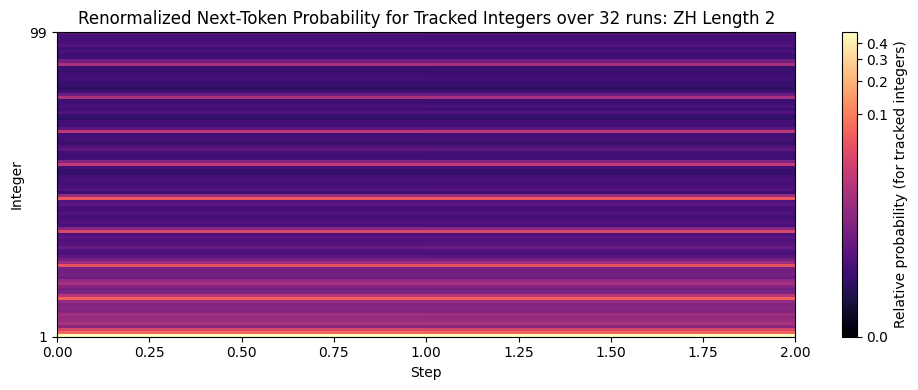

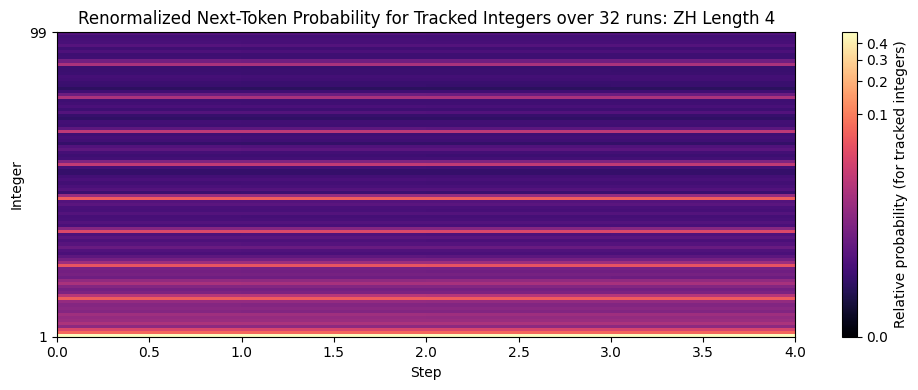

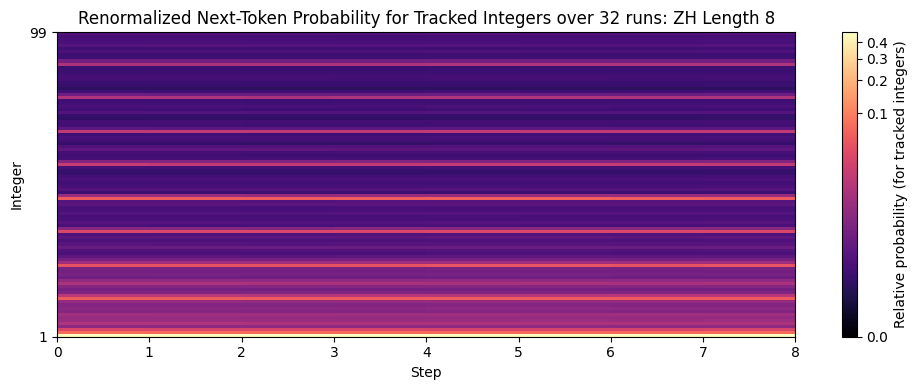

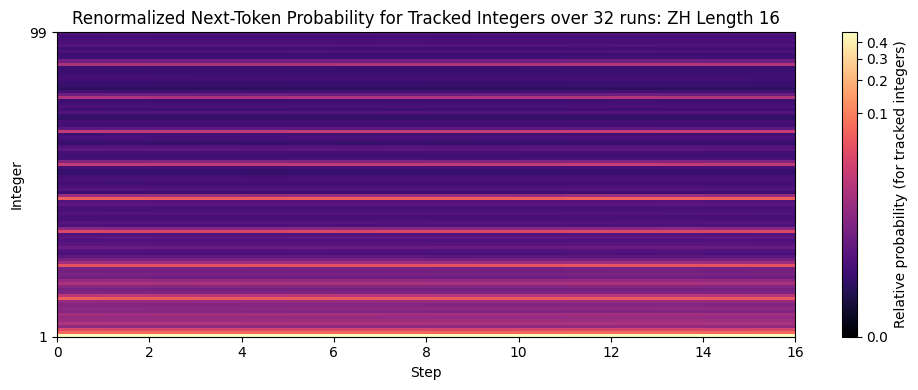

In [5]:
ZH_ROLLOUTS = ROOT / 'rollouts' / 'zh'

paths = list(ZH_ROLLOUTS.glob('*.json'))

def sort_key(p: Path):
    # expect like en_len16_rollouts32.json
    stem = p.stem
    for part in stem.split('_'):
        if part.startswith('len'):
            try:
                return int(part.removeprefix('len'))
            except ValueError:
                return 0
    return 0

for path in sorted(paths, key=sort_key):
    data = json.loads(path.read_text())
    steps = data['per_step_probs']
    ints = sorted(steps[0].keys())
    mat = np.array([[step[i] for i in ints] for step in steps], dtype=np.float32)
    mat_rel = mat / (mat.sum(axis=1, keepdims=True) + 1e-12)

    vmax = np.percentile(mat_rel, 99.5)
    norm = colors.PowerNorm(gamma=0.2, vmin=0, vmax=vmax)

    plt.figure(figsize=(10, 4))
    im = plt.imshow(
        mat_rel.T,
        aspect='auto',
        origin='lower',
        extent=[0, mat.shape[0], min(ints), max(ints)],
        cmap='magma',
        norm=norm,
    )
    plt.colorbar(im, label='Relative probability (for tracked integers)')
    plt.xlabel('Step')
    plt.ylabel('Integer')
    plt.title(human_title(path))
    plt.tight_layout()
    plt.savefig(f"{path.name[:-5]}-heatmap.png", dpi=300, bbox_inches="tight")
    plt.show()

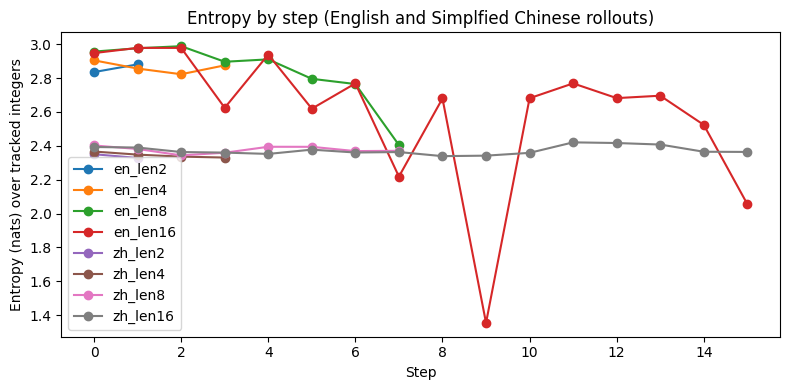

In [6]:
EN_ROLLOUTS = ROOT / 'rollouts' / 'en'
ZH_ROLLOUTS = ROOT / 'rollouts' / 'zh'

def sort_key(p: Path):
    stem = p.stem  # e.g., en_len16_rollouts32
    for part in stem.split('_'):
        if part.startswith('len'):
            try:
                return int(part.removeprefix('len'))
            except ValueError:
                return 0
    return 0

def load_entropy(path: Path):
    data = json.loads(path.read_text())
    steps = data['per_step_probs']
    ints = sorted(steps[0].keys())
    mat = np.array([[step[i] for i in ints] for step in steps], dtype=np.float32)
    mat_rel = mat / (mat.sum(axis=1, keepdims=True) + 1e-12)
    entropy = -(mat_rel * np.log(mat_rel + 1e-12)).sum(axis=1)
    return entropy

plt.figure(figsize=(8,4))

for lang, base in [('en', EN_ROLLOUTS), ('zh', ZH_ROLLOUTS)]:
    for path in sorted(base.glob('*.json'), key=sort_key):
        length = sort_key(path)
        entropy = load_entropy(path)
        plt.plot(range(len(entropy)), entropy, marker='o', label=f"{lang}_len{length}")

plt.xlabel('Step')
plt.ylabel('Entropy (nats) over tracked integers')
plt.title('Entropy by step (English and Simplfied Chinese rollouts)')
plt.legend()
plt.tight_layout()
plt.show()

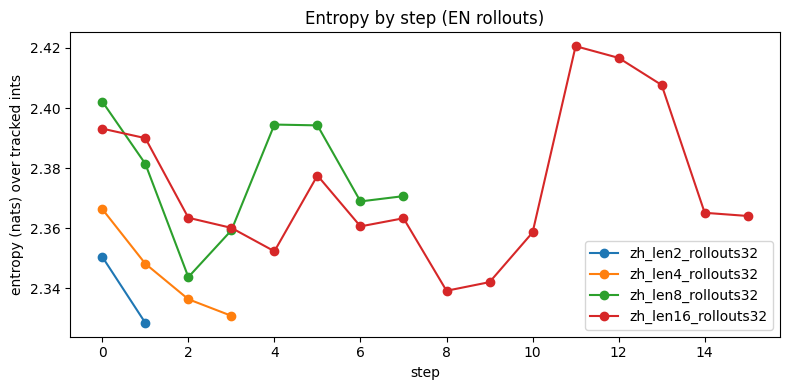

In [7]:
paths = list(ZH_ROLLOUTS.glob('*.json'))

def sort_key(p: Path):
    # expect like zh_len16_rollouts32.json
    stem = p.stem
    for part in stem.split('_'):
        if part.startswith('len'):
            try:
                return int(part.removeprefix('len'))
            except ValueError:
                return 0
    return 0

plt.figure(figsize=(8,4))
for path in sorted(paths, key=sort_key):
    data = json.loads(path.read_text())
    steps = data['per_step_probs']
    ints = sorted(steps[0].keys())
    mat = np.array([[step[i] for i in ints] for step in steps], dtype=np.float32)
    mat_rel = mat / (mat.sum(axis=1, keepdims=True) + 1e-12)
    entropy = -(mat_rel * np.log(mat_rel + 1e-12)).sum(axis=1)
    plt.plot(range(mat.shape[0]), entropy, marker='o', label=path.stem)

plt.xlabel('step')
plt.ylabel('entropy (nats) over tracked ints')
plt.title('Entropy by step (EN rollouts)')
plt.legend()
plt.tight_layout()
plt.show()

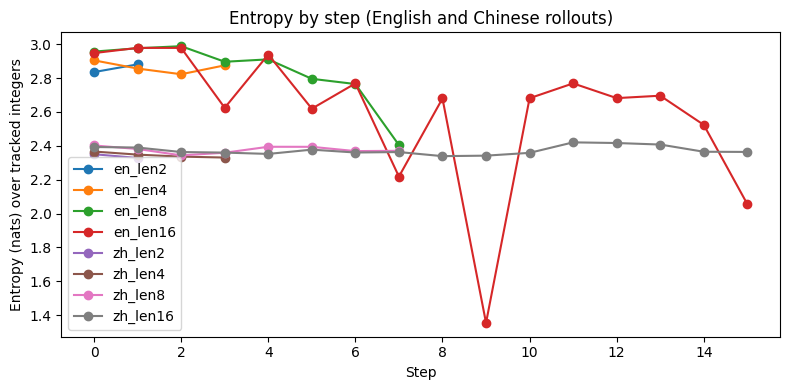

Entropy stats (nats) per length:
  len 2: mean en=2.8586 (std=0.0228), zh=2.3395 (std=0.0110), |Δmean|=0.5192; median en=2.8586, zh=2.3395, |Δmedian|=0.5192
  len 4: mean en=2.8651 (std=0.0298), zh=2.3454 (std=0.0136), |Δmean|=0.5197; median en=2.8661, zh=2.3423, |Δmedian|=0.5238
  len 8: mean en=2.8370 (std=0.1802), zh=2.3769 (std=0.0187), |Δmean|=0.4601; median en=2.9039, zh=2.3761, |Δmedian|=0.5278
  len 16: mean en=2.5949 (std=0.4039), zh=2.3734 (std=0.0243), |Δmean|=0.2215; median en=2.6817, zh=2.3638, |Δmedian|=0.3179


{'en': {2: [(0, 2.835836410522461), (1, 2.881452798843384)],
  4: [(0, 2.9050374031066895),
   (1, 2.856565475463867),
   (2, 2.8231072425842285),
   (3, 2.8755877017974854)],
  8: [(0, 2.9569764137268066),
   (1, 2.9764933586120605),
   (2, 2.9889063835144043),
   (3, 2.8967936038970947),
   (4, 2.9109396934509277),
   (5, 2.7960216999053955),
   (6, 2.7651329040527344),
   (7, 2.404754161834717)],
  16: [(0, 2.9480957984924316),
   (1, 2.9787580966949463),
   (2, 2.9785821437835693),
   (3, 2.6246840953826904),
   (4, 2.93943452835083),
   (5, 2.619529962539673),
   (6, 2.7689101696014404),
   (7, 2.218309164047241),
   (8, 2.679927110671997),
   (9, 1.353990077972412),
   (10, 2.6813690662384033),
   (11, 2.7690517902374268),
   (12, 2.682011127471924),
   (13, 2.696241617202759),
   (14, 2.523768663406372),
   (15, 2.0556304454803467)]},
 'zh': {2: [(0, 2.3504509925842285), (1, 2.328467607498169)],
  4: [(0, 2.3663535118103027),
   (1, 2.348172187805176),
   (2, 2.3363425731658936)

In [8]:
from pathlib import Path
import json, numpy as np, matplotlib.pyplot as plt

EN_ROLLOUTS = ROOT / 'rollouts' / 'en'
ZH_ROLLOUTS = ROOT / 'rollouts' / 'zh'

def sort_key(p: Path):
    stem = p.stem  # e.g., en_len16_rollouts32
    for part in stem.split('_'):
        if part.startswith('len'):
            try:
                return int(part.removeprefix('len'))
            except ValueError:
                return 0
    return 0

def load_entropy(path: Path):
    data = json.loads(path.read_text())
    steps = data['per_step_probs']
    ints = sorted(steps[0].keys())
    mat = np.array([[step[i] for i in ints] for step in steps], dtype=np.float32)
    mat_rel = mat / (mat.sum(axis=1, keepdims=True) + 1e-12)
    entropy = -(mat_rel * np.log(mat_rel + 1e-12)).sum(axis=1)
    return entropy

plt.figure(figsize=(8,4))

avg_ent_by_lang = {"en": {}, "zh": {}}
med_ent_by_lang = {"en": {}, "zh": {}}
std_ent_by_lang = {"en": {}, "zh": {}}
points_by_seq = {"en": {}, "zh": {}}

for lang, base in [('en', EN_ROLLOUTS), ('zh', ZH_ROLLOUTS)]:
    for path in sorted(base.glob('*.json'), key=sort_key):
        length = sort_key(path)
        entropy = load_entropy(path)
        seq_points = [(step, float(value)) for step, value in enumerate(entropy)]
        points_by_seq[lang][length] = seq_points
        plt.plot(range(len(entropy)), entropy, marker='o', label=f"{lang}_len{length}")
        avg_ent_by_lang[lang][length] = float(entropy.mean())
        med_ent_by_lang[lang][length] = float(np.median(entropy))
        std_ent_by_lang[lang][length] = float(entropy.std())

plt.xlabel('Step')
plt.ylabel('Entropy (nats) over tracked integers')
plt.title('Entropy by step (English and Chinese rollouts)')
plt.legend()
plt.tight_layout()
plt.show()

# Print stats per length and abs differences
en_avg, zh_avg = avg_ent_by_lang["en"], avg_ent_by_lang["zh"]
en_med, zh_med = med_ent_by_lang["en"], med_ent_by_lang["zh"]
en_std, zh_std = std_ent_by_lang["en"], std_ent_by_lang["zh"]
common_lengths = sorted(set(en_avg.keys()) & set(zh_avg.keys()))

print("Entropy stats (nats) per length:")
for L in common_lengths:
    diff_mean = abs(en_avg[L] - zh_avg[L])
    diff_med = abs(en_med[L] - zh_med[L])
    print(
        f"  len {L}: "
        f"mean en={en_avg[L]:.4f} (std={en_std[L]:.4f}), "
        f"zh={zh_avg[L]:.4f} (std={zh_std[L]:.4f}), |Δmean|={diff_mean:.4f}; "
        f"median en={en_med[L]:.4f}, zh={zh_med[L]:.4f}, |Δmedian|={diff_med:.4f}"
    )

points_by_seq



In [9]:
for path in npz_paths:
    if not path.exists():
        print(f"Missing: {path}")
        continue
    summary = summarize_dataset(path)
    print_report(summary)
    print()

File: /home/kevwjin/Documents/Fall2025/Cs228_BioSecAi/RecoverResearch/Research/artifacts/en-len16-n8192-rep1.npz
  shape=(8192, 16), dtype=int64
  min=1, max=99
  unique rows=8192, duplicate rows=0, duplicate entries=0
  global uniform test: chi2=241280.69, dof=98, p=0.000e+00
  value frequency outliers (value, count, z):
    1: count=13, z=-36.03
    2: count=354, z=-26.66
    3: count=130, z=-32.81
    5: count=231, z=-30.04
    6: count=93, z=-33.83
    7: count=602, z=-19.84
    8: count=418, z=-24.90
    9: count=410, z=-25.12
    10: count=17, z=-35.92
    11: count=4285, z=81.38
    12: count=447, z=-24.10
    13: count=7720, z=175.78
    14: count=1913, z=16.19
    15: count=327, z=-27.40
    16: count=1, z=-36.36
    17: count=420, z=-24.84
    18: count=1186, z=-3.79
    19: count=5608, z=117.74
    20: count=33, z=-35.48
    21: count=1618, z=8.08
    22: count=1092, z=-6.37
    23: count=1835, z=14.04
    24: count=1452, z=3.52
    25: count=2291, z=26.58
    26: count=283,

In [10]:
for p in npz_paths:
    with np.load(p) as d:
        arr = d["sequences"]  # shape (N, 16)
    mask = (arr < 1) | (arr > 100)
    tokens_oor = int(mask.sum())
    seqs_oor = int(mask.any(axis=1).sum())
    total_tokens = arr.size
    print(
        f"{p.name}: tokens OOR={tokens_oor}/{total_tokens}, "
        f"seqs with any OOR={seqs_oor}/{arr.shape[0]}, "
        f"min={arr.min()}, max={arr.max()}"
    )

en-len16-n8192-rep1.npz: tokens OOR=0/131072, seqs with any OOR=0/8192, min=1, max=99
en-len16-n8192-rep2.npz: tokens OOR=0/131072, seqs with any OOR=0/8192, min=1, max=99
en-llm-hist-len16-n8192-rep1.npz: tokens OOR=0/131072, seqs with any OOR=0/8192, min=1, max=99
en-llm-hist-len8-n8192-rep1.npz: tokens OOR=0/65536, seqs with any OOR=0/8192, min=1, max=99
prng-len16-n8192-rep1.npz: tokens OOR=0/131072, seqs with any OOR=0/8192, min=1, max=100
prng-len16-n8192-rep2.npz: tokens OOR=0/131072, seqs with any OOR=0/8192, min=1, max=100
zh-llm-hist-len16-n8192-rep1.npz.checkpoint.npz: tokens OOR=45/20480, seqs with any OOR=42/1280, min=1, max=102
zh-llm-len16-n8192-rep1.npz: tokens OOR=3/131072, seqs with any OOR=2/8192, min=1, max=121
zh-llm-len16-n8192-rep2.npz: tokens OOR=1/131072, seqs with any OOR=1/8192, min=0, max=100


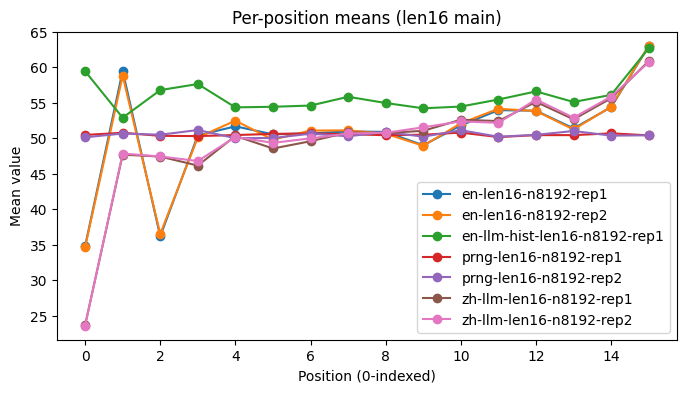

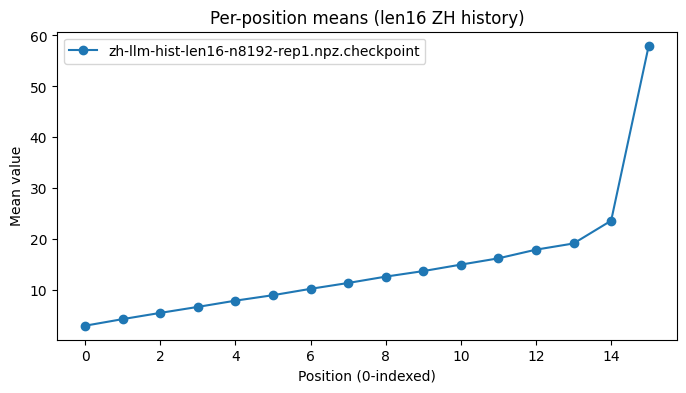

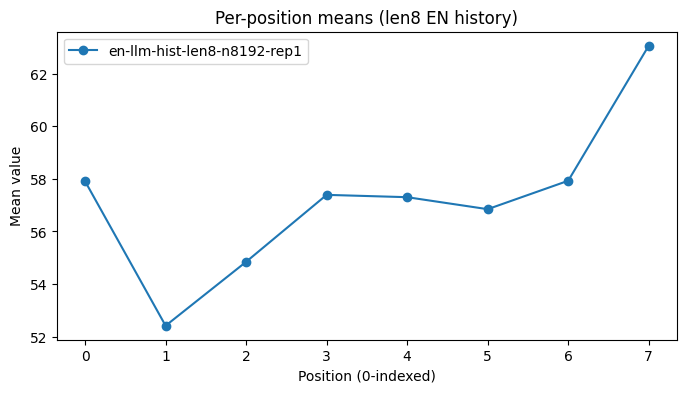

In [11]:
def plot_group(paths, title):
    fig, ax = plt.subplots(figsize=(8,4))
    for p in paths:
        arr = np.load(p)["sequences"]
        means = arr.mean(axis=0)
        ax.plot(range(len(means)), means, marker="o", label=p.stem)
    ax.set_xlabel("Position (0-indexed)")
    ax.set_ylabel("Mean value")
    ax.set_title(title)
    ax.legend()
    plt.show()

plot_group(sorted(len16_main), "Per-position means (len16 main)")
if len16_hist:
    plot_group(sorted(len16_hist), "Per-position means (len16 ZH history)")
if len8_hist:
    plot_group(sorted(len8_hist), "Per-position means (len8 EN history)")

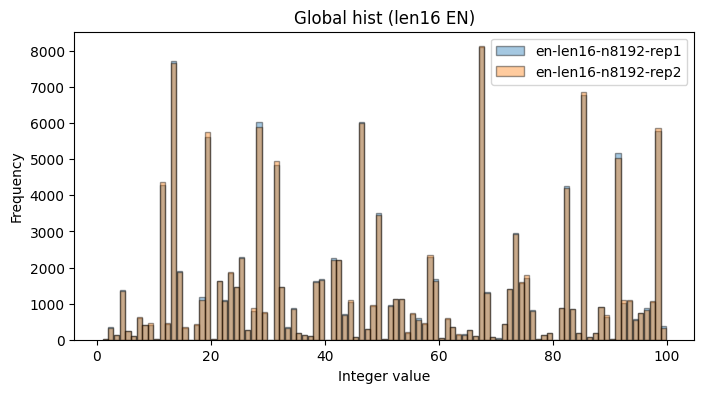

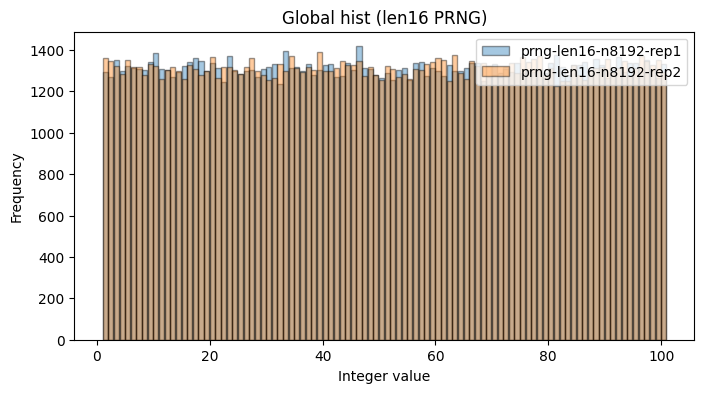

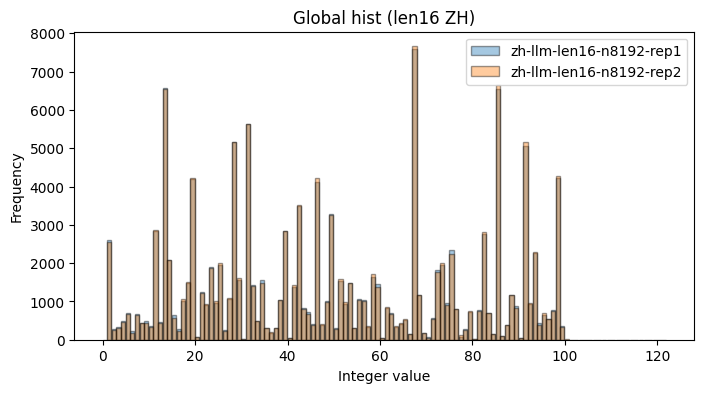

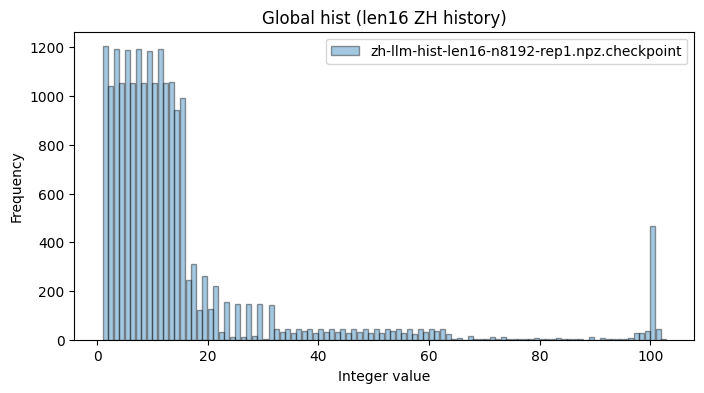

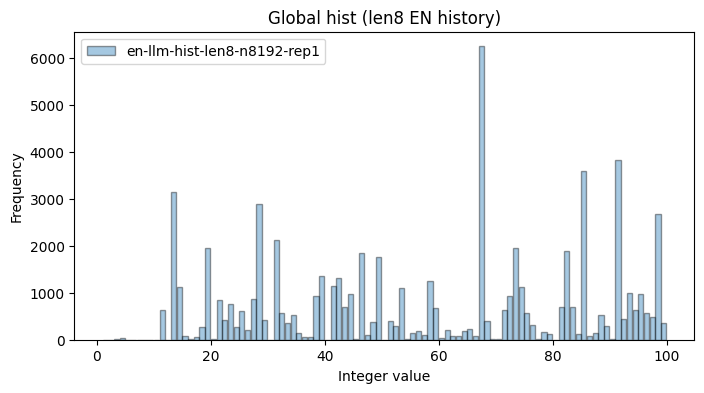

In [12]:
# len16_main = []
# ax.set_xlabel("Integer value")
# ax.set_ylabel("Frequency")
# ax.set_title(title)
# ax.legend()
# plt.show()

def plot_group_hist(paths, title):
    fig, ax = plt.subplots(figsize=(8,4))
    for p in paths:
        arr = np.load(p)["sequences"]
        flat = arr.reshape(-1)
        min_v, max_v = int(flat.min()), int(flat.max())
        bins = max_v - min_v + 1
        counts, edges = np.histogram(flat, bins=bins, range=(min_v, max_v + 1))
        ax.bar(edges[:-1], counts, width=0.9, align="edge", edgecolor="black", alpha=0.4, label=p.stem)
    ax.set_xlabel("Integer value")
    ax.set_ylabel("Frequency")
    ax.set_title(title)
    ax.legend()
    plt.show()
    
len16_main = sorted(len16_main)
plot_group_hist(len16_main[:2], "Global hist (len16 EN)")
plot_group_hist(len16_main[3:5], "Global hist (len16 PRNG)")
plot_group_hist(len16_main[5:], "Global hist (len16 ZH)")
plot_group_hist(sorted(len16_hist), "Global hist (len16 ZH history)")
plot_group_hist(sorted(len8_hist), "Global hist (len8 EN history)")

In [13]:
!python ../train_lstm_classifier.py --data ../artifacts/splits/en-split.npz --epochs 10 --batch-size 128
!python ../train_lstm_classifier.py --data ../artifacts/splits/zh-split.npz --epochs 10 --batch-size 128
!python ../train_lstm_classifier.py --data ../artifacts/splits/prng-split.npz --epochs 10 --batch-size 128

Shifted by 0; vocab_size=99; min=0, max=98
Epoch 01: train_loss=3.9311 train_acc=0.153 | val_loss=3.4683 val_acc=0.215
Epoch 02: train_loss=3.2504 train_acc=0.250 | val_loss=3.1070 val_acc=0.269
Epoch 03: train_loss=2.9801 train_acc=0.292 | val_loss=2.9199 val_acc=0.293
Epoch 04: train_loss=2.8225 train_acc=0.315 | val_loss=2.8030 val_acc=0.310
Epoch 05: train_loss=2.7176 train_acc=0.329 | val_loss=2.7274 val_acc=0.319
Epoch 06: train_loss=2.6430 train_acc=0.339 | val_loss=2.6705 val_acc=0.330
Epoch 07: train_loss=2.5888 train_acc=0.345 | val_loss=2.6318 val_acc=0.334
Epoch 08: train_loss=2.5473 train_acc=0.351 | val_loss=2.6013 val_acc=0.335
Epoch 09: train_loss=2.5118 train_acc=0.355 | val_loss=2.5806 val_acc=0.340
Epoch 10: train_loss=2.4828 train_acc=0.359 | val_loss=2.5641 val_acc=0.341
Test: loss=2.5574 acc=0.341
Saved model to artifacts/en-split-lstm.pt
Shifted by -1; vocab_size=122; min=0, max=121
Epoch 01: train_loss=4.1282 train_acc=0.143 | val_loss=3.6685 val_acc=0.187
Epoch

en training range=(0,98), vocab=99
zh training range=(-1,120), vocab=122
prng training range=(0,99), vocab=100
Probe shapes: {'en': (1000, 16), 'zh': (1000, 16), 'prng': (1000, 16)}
--- Model en ---
Probe en: loss=2.5370 acc=0.341
Probe zh: loss=3.2761 acc=0.245
Probe prng: loss=6.4649 acc=0.010

--- Model zh ---
Probe en: loss=2.9117 acc=0.274
Probe zh: loss=2.7389 acc=0.310
Probe prng: loss=6.0517 acc=0.010

--- Model prng ---
Probe en: loss=4.6853 acc=0.010
Probe zh: loss=4.6809 acc=0.010
Probe prng: loss=4.6688 acc=0.009

Saved results to ../artifacts/probe_losses.json


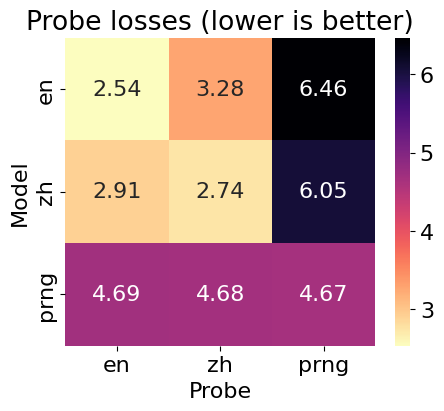

In [29]:
# Run probe_losses via CLI to produce JSON
!python ../probe_losses.py --en-split ../artifacts/splits/en-split.npz --zh-split ../artifacts/splits/zh-split.npz --prng-split ../artifacts/splits/prng-split.npz --en-model ../artifacts/en-split-lstm.pt --zh-model ../artifacts/zh-split-lstm.pt --prng-model ../artifacts/prng-split-lstm.pt --probe-count 1000 --out-json ../artifacts/probe_losses.json

with open("../artifacts/probe_losses.json") as f:
    results = json.load(f)
models = ["en","zh","prng"]
probes = ["en","zh","prng"]
df = pd.DataFrame([[results[m][p]["loss"] for p in probes] for m in models], index=models, columns=probes)

plt.figure(figsize=(5,4))
sns.heatmap(df, annot=True, fmt=".2f", cmap="magma_r")
plt.title("Probe losses (lower is better)")
plt.xlabel("Probe")
plt.ylabel("Model")
plt.savefig(f"{path.name[:-5]}-confusion-matrix.png", dpi=300, bbox_inches="tight")
plt.show()

EN shift=0, vocab=99; ZH shift=0, vocab=121
Fitted coeffs (bias, b_loss_en, c_loss_zh): [ 8.45688479 -1.52482381 -0.64766876]
prop_en, loss_en, loss_zh, acc_en, acc_zh, inferred_en_prop
0.00, 3.2658, 5.3294, 0.250, 0.025, 0.025
0.25, 3.0533, 5.4342, 0.273, 0.015, 0.282
0.50, 2.9524, 5.4323, 0.297, 0.021, 0.437
0.75, 2.7367, 5.5106, 0.309, 0.011, 0.715
1.00, 2.5015, 5.5599, 0.353, 0.010, 1.000
Saved mixture results to ../artifacts/mixture.json


,true_en,loss_en,loss_zh,acc_en,acc_zh,inferred_en
0,0.00,3.265832,5.329445,0.249867,0.024533,0.025351
1,0.25,3.053254,5.434221,0.272800,0.014933,0.281636
2,0.50,2.952430,5.432283,0.297067,0.021333,0.436629
3,0.75,2.736665,5.510635,0.308933,0.011467,0.714887
4,1.00,2.501532,5.559929,0.353467,0.010400,1.000000


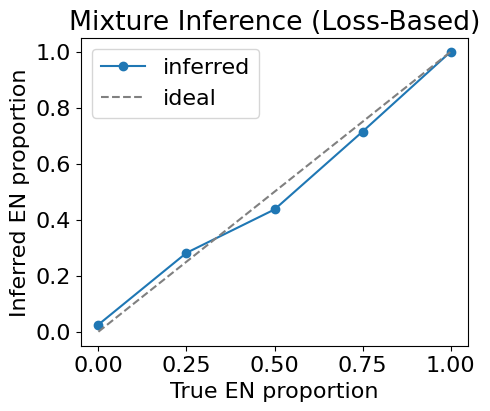

In [30]:
# Generate JSON (adjust paths if needed)
!python ../mixture_inference.py --en-split ../artifacts/splits/en-split.npz --zh-split ../artifacts/splits/zh-split.npz --en-model ../artifacts/en-split-lstm.pt --zh-model ../artifacts/zh-split-lstm.pt --probe-count 500 --out-json ../artifacts/mixture.json

with open("../artifacts/mixture.json") as f:
    mix_json = json.load(f)
dfm = pd.DataFrame(mix_json["rows"])
display(dfm)

plt.figure(figsize=(5,4))
plt.plot(dfm["true_en"], dfm["inferred_en"], marker="o", label="inferred")
plt.plot([0,1],[0,1], linestyle="--", color="gray", label="ideal")
plt.xlabel("True EN proportion")
plt.ylabel("Inferred EN proportion")
plt.legend()
plt.title("Mixture Inference (Loss-Based)")
plt.savefig(f"{path.name[:-5]}-sdf.png", dpi=300, bbox_inches="tight")
plt.show()

In [31]:
from probe_gradients import load_model, create_loader, grad_vector
from train_lstm_classifier import get_device, load_split

ARTIFACTS = ROOT / "artifacts"
SPLITS = {
    "en": ARTIFACTS / "splits" / "en-split.npz",
    "zh": ARTIFACTS / "splits" / "zh-split.npz",
    "prng": ARTIFACTS / "splits" / "prng-split.npz",
}
CKPTS = {
    "en": ARTIFACTS / "en-split-lstm.pt",
    "zh": ARTIFACTS / "zh-split-lstm.pt",
    "prng": ARTIFACTS / "prng-split-lstm.pt",
}


def collect_grad_matrix(probe_count: int = 200, batch_size: int = 128) -> pd.DataFrame:
    """Mirror probe_gradients.py but return a dataframe for visualization."""
    device = get_device()
    criterion = nn.CrossEntropyLoss()
    rng = np.random.default_rng(42)

    specs: dict[str, dict[str, int]] = {}
    probes: dict[str, np.ndarray] = {}
    for name, split_path in SPLITS.items():
        tr, val, te = load_split(split_path)
        gmin = int(min(tr.min(), val.min(), te.min()))
        gmax = int(max(tr.max(), val.max(), te.max()))
        if probe_count and probe_count < te.shape[0]:
            te = te[rng.choice(te.shape[0], size=probe_count, replace=False)]
        specs[name] = {"shift": gmin, "vocab": gmax - gmin + 1}
        probes[name] = te

    models = {
        name: load_model(CKPTS[name], specs[name]["vocab"], 64, 128, 1, 0.1, device)
        for name in SPLITS
    }

    rows: list[dict[str, float | str]] = []
    for model_name, model in models.items():
        m_shift = specs[model_name]["shift"]
        m_vocab = specs[model_name]["vocab"]
        for probe_name, arr in probes.items():
            shifted = np.clip(arr - m_shift, 0, m_vocab - 1)
            loader = create_loader(shifted, batch_size)
            model.zero_grad(set_to_none=True)
            total_loss = 0.0
            total_tokens = 0
            for inputs, targets in loader:
                inputs = inputs.to(device)
                targets = targets.to(device)
                logits = model(inputs)
                loss = criterion(logits.view(-1, logits.size(-1)), targets.view(-1))
                loss.backward()
                total_loss += loss.item() * targets.numel()
                total_tokens += targets.numel()
            gvec = grad_vector(model)
            grad_norm = gvec.norm().item() if gvec.numel() else 0.0
            rows.append(
                {
                    "model": model_name,
                    "probe": probe_name,
                    "avg_loss": total_loss / total_tokens,
                    "grad_norm": grad_norm,
                }
            )
    return pd.DataFrame(rows)


def plot_grad_confusion(df: pd.DataFrame) -> None:
    """Pivot dataframe and display a confusion-matrix-style heatmap."""
    order = ["en", "zh", "prng"]
    mat = (
        df.pivot(index="model", columns="probe", values="grad_norm")
        .reindex(order, axis=0)
        .reindex(order, axis=1)
    )
    sns.heatmap(
        mat,
        annot=mat.applymap(lambda x: f"{x:.2f}"),
        fmt="",
        cmap="magma_r",
    )
    plt.title("Gradient Norm Confusion Matrix (darker = better match)")
    plt.ylabel("Model")
    plt.xlabel("Probe")
    plt.savefig(f"{path.name[:-5]}-sdf2.png", dpi=300, bbox_inches="tight")
    plt.show()


if __name__ == "__main__":
    df = collect_grad_matrix()
    plot_grad_confusion(df)

AttributeError: 'DataFrame' object has no attribute 'applymap'

In [ ]:
# Generate JSON (adjust paths if needed)
!python ../mixture_inference_gradients.py \
  --en-split ../artifacts/splits/en-split.npz \
  --zh-split ../artifacts/splits/zh-split.npz \
  --en-model ../artifacts/en-split-lstm.pt \
  --zh-model ../artifacts/zh-split-lstm.pt \
  --probe-count 500 \
  --out-json ../artifacts/mixture_gradients.json

with open("../artifacts/mixture_gradients.json") as f:
  mix_json = json.load(f)

dfm = pd.DataFrame(mix_json["rows"])
display(dfm)

plt.figure(figsize=(5, 4))
plt.plot(dfm["true_en"], dfm["inferred_en"], marker="o",
label="inferred")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray",
label="ideal")
plt.xlabel("True EN proportion")
plt.ylabel("Inferred EN proportion")
plt.legend()
plt.title("Mixture inference (Gradient-Based)")
plt.savefig(f"{path.name[:-5]}-cm.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
from mixture_notebook_helpers import run_and_display

df_loss = run_and_display("loss", probe_count=500)
df_grad = run_and_display("gradient", probe_count=500)